# 06 — Análise exploratória dos clusters de risco no Paraná

Recorte: genomas `WHO_Priority == "Critical"` com `Estado == "PR"`, rotulados pelos 6 clusters de
`04_clusterizacao_risco` (`data/processed/clusters_risco.csv`).

**Aviso de viés antes de tudo**: o PR tem poucos genomas (~110) e eles não são uma amostra
aleatória do estado. São o que foi depositado em bancos públicos, e um único estudo (um lote de
BioSamples consecutivos) domina o recorte. Por isso a seção 2 identifica os lotes de submissão
**antes** de qualquer comparação, e as comparações PR × Brasil são refeitas controlando espécie
(seção 6) e sem o lote dominante (seção 3.1).

Roteiro:
1. Dados e normalização de cidade
2. Lotes de submissão (quem gerou esses genomas?)
3. Distribuição dos clusters: PR × resto do Brasil
4. Espécie, cidade e fonte
5. Linha do tempo
6. *E. coli*: PR × resto do Brasil (controlando espécie)
7. Quais genes estão por trás dos clusters no PR
8. Resumo

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore", category=FutureWarning)


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from notebooks.src.features_risco import CatalogoBetaLactamase, anotar_resistoma_risco

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

ROTULO = {
    0: "C0 MBL+ESBL",
    1: "C1 ESBL",
    2: "C2 carb. serina",
    3: "C3 carb. serina+ESBL",
    4: "C4 carb.+metilase 16S",
    5: "C5 sem mecanismo",
}
ORDEM = list(ROTULO.values())
CORES = dict(zip(ORDEM, sns.color_palette("tab10", 6)))

## 1. Dados

In [2]:
clusters = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
df = clusters.join(metadata.drop(columns=["Species"]), how="left")
df["cl"] = pd.Categorical(df["cluster"].map(ROTULO), categories=ORDEM, ordered=True)
df["uf"] = np.where(df["Estado"] == "PR", "PR", np.where(df["Estado"].notna(), "outras UF", "UF desconhecida"))

pr = df[df["Estado"] == "PR"].copy()
print(f"Brasil (recorte Critical): {len(df)} | PR: {len(pr)} ({len(pr) / len(df):.1%})")

Brasil (recorte Critical): 2226 | PR: 111 (5.0%)


### Cidade

`Location` vem em formatos diferentes ("Londrina", "Londrina, Parana", "Parana, Curitiba",
"Hospital de Clinicas of Universidade Federal do Parana"...). Aqui ela é normalizada para a cidade.
O Hospital de Clínicas da UFPR fica em Curitiba.

In [3]:
CIDADES = {"londrina": "Londrina", "curitiba": "Curitiba", "maring": "Maringá", "cascavel": "Cascavel",
           "universidade federal do parana": "Curitiba"}


def normaliza_cidade(loc):
    s = str(loc).lower()
    for chave, cidade in CIDADES.items():
        if chave in s:
            return cidade
    return "PR (sem cidade)"


pr["cidade"] = pr["Location"].apply(normaliza_cidade)
pd.crosstab(pr["Location"], pr["cidade"])

cidade,Cascavel,Curitiba,Londrina,Maringá,PR (sem cidade)
Location,,,,,
Cascavel,1,0,0,0,0
Curitiba,0,9,0,0,0
Hospital de Clinicas of Universidade Federal do Parana,0,1,0,0,0
Londrina,0,0,74,0,0
"Londrina, Parana",0,0,9,0,0
Maringa,0,0,0,8,0
Parana,0,0,0,0,2
Parana State,0,0,0,0,1
"Parana, Curitiba",0,6,0,0,0


## 2. Lotes de submissão

BioSamples com números consecutivos (diferença < 2000) foram quase sempre submetidos juntos, pelo
mesmo grupo e no mesmo projeto. Um lote grande = um estudo, com o desenho amostral dele (uma espécie,
um hospital, um tipo de amostra). Esse é o principal viés de qualquer análise regional com genomas
públicos.

In [4]:
pr["biosample_num"] = pr["BioSample"].str.extract(r"(\d+)")[0].astype(float)
pr = pr.sort_values("biosample_num")
pr["lote"] = (pr["biosample_num"].diff() > 2000).cumsum()


def resumo_top(s, n=2):
    return ", ".join(f"{k} ({v})" for k, v in s.value_counts().head(n).items())


lotes = pr.groupby("lote").agg(
    n=("cluster", "size"),
    biosamples=("BioSample", lambda s: f"{s.iloc[0]} … {s.iloc[-1]}" if len(s) > 1 else s.iloc[0]),
    especie=("Species", resumo_top),
    cidade=("cidade", resumo_top),
    fonte=("source_type", resumo_top),
    anos=("Date", lambda s: f"{int(s.min())}–{int(s.max())}" if s.notna().any() else "?"),
    clusters=("cl", lambda s: resumo_top(s, 3)),
).sort_values("n", ascending=False)
lotes

,n,biosamples,especie,cidade,fonte,anos,clusters
lote,,,,,,,
4,62,SAMN13058723 … SAMN13058785,Escherichia coli (62),Londrina (62),Urinary (62),2016–2019,"C1 ESBL (41), C5 sem mecanismo (19), C4 carb.+metilase 16S (1)"
13,8,SAMN44026661 … SAMN44026668,Proteus mirabilis (8),Londrina (8),Urinary (8),2022–2022,"C5 sem mecanismo (7), C2 carb. serina (1), C1 ESBL (0)"
5,8,SAMN14484993 … SAMN14485814,Escherichia coli (8),"Maringá (7), Londrina (1)","Urinary (5), Gastrointestinal (2)",2015–2019,"C1 ESBL (4), C0 MBL+ESBL (3), C2 carb. serina (1)"
16,7,SAMN48065935 … SAMN48065941,Acinetobacter baumannii (7),Londrina (7),"Blood (6), Urinary (1)",2020–2023,"C4 carb.+metilase 16S (5), C2 carb. serina (1), C3 carb. serina+ESBL (1)"
2,6,SAMN06350007 … SAMN06350012,Klebsiella pneumoniae (6),Curitiba (6),"Gastrointestinal (2), Blood (2)",2005–2011,"C3 carb. serina+ESBL (4), C1 ESBL (2), C0 MBL+ESBL (0)"
6,5,SAMN14529285 … SAMN14529289,Escherichia coli (5),"Londrina (3), Cascavel (1)","Gastrointestinal (2), Urinary (2)",2017–2017,"C5 sem mecanismo (3), C1 ESBL (2), C0 MBL+ESBL (0)"
15,5,SAMN46841722 … SAMN46841726,Klebsiella pneumoniae (5),Curitiba (5),"Blood (3), Gastrointestinal (2)",2022–2023,"C3 carb. serina+ESBL (4), C2 carb. serina (1), C1 ESBL (0)"
0,1,SAMN04445568,Klebsiella aerogenes (1),Curitiba (1),Blood (1),2007–2007,"C1 ESBL (1), C0 MBL+ESBL (0), C2 carb. serina (0)"
3,1,SAMN09222159,Proteus mirabilis (1),Londrina (1),Respiratory (1),2015–2015,"C1 ESBL (1), C0 MBL+ESBL (0), C2 carb. serina (0)"


In [5]:
LOTE_DOMINANTE = lotes.index[0]
n_dom = lotes.loc[LOTE_DOMINANTE, "n"]
pr["lote_dominante"] = pr["lote"] == LOTE_DOMINANTE
print(f"Lote dominante: {n_dom} de {len(pr)} genomas do PR ({n_dom / len(pr):.0%}) — "
      f"{lotes.loc[LOTE_DOMINANTE, 'especie']}, {lotes.loc[LOTE_DOMINANTE, 'cidade']}, "
      f"{lotes.loc[LOTE_DOMINANTE, 'fonte']}, {lotes.loc[LOTE_DOMINANTE, 'anos']}")

Lote dominante: 62 de 111 genomas do PR (56%) — Escherichia coli (62), Londrina (62), Urinary (62), 2016–2019


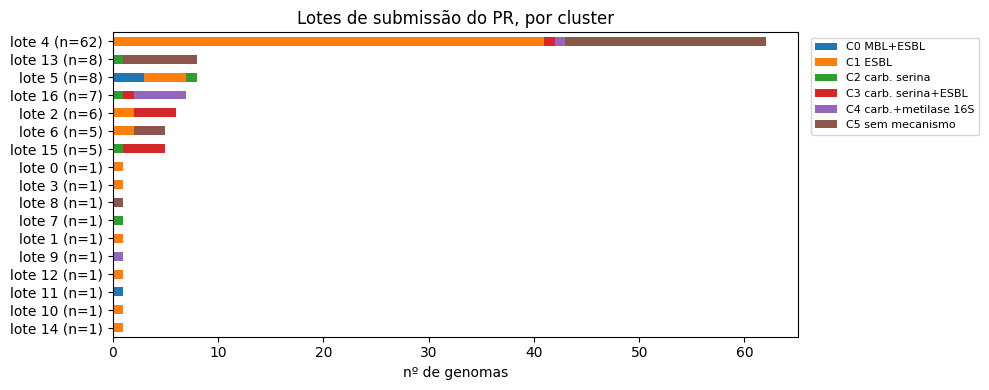

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ordem_lotes = lotes.index.tolist()
ct = pd.crosstab(pr["lote"], pr["cl"]).reindex(ordem_lotes)
ct.index = [f"lote {i} (n={lotes.loc[i, 'n']})" for i in ordem_lotes]
ct.plot(kind="barh", stacked=True, ax=ax, color=[CORES[c] for c in ct.columns])
ax.invert_yaxis()
ax.set(xlabel="nº de genomas", ylabel="", title="Lotes de submissão do PR, por cluster")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Distribuição dos clusters: PR × resto do Brasil

Proporção de cada cluster com intervalo de confiança de Wilson (95%), que é adequado para n pequeno.
"Resto do Brasil" = genomas com UF conhecida fora do PR. Os ~40% sem UF ficam de fora da comparação.

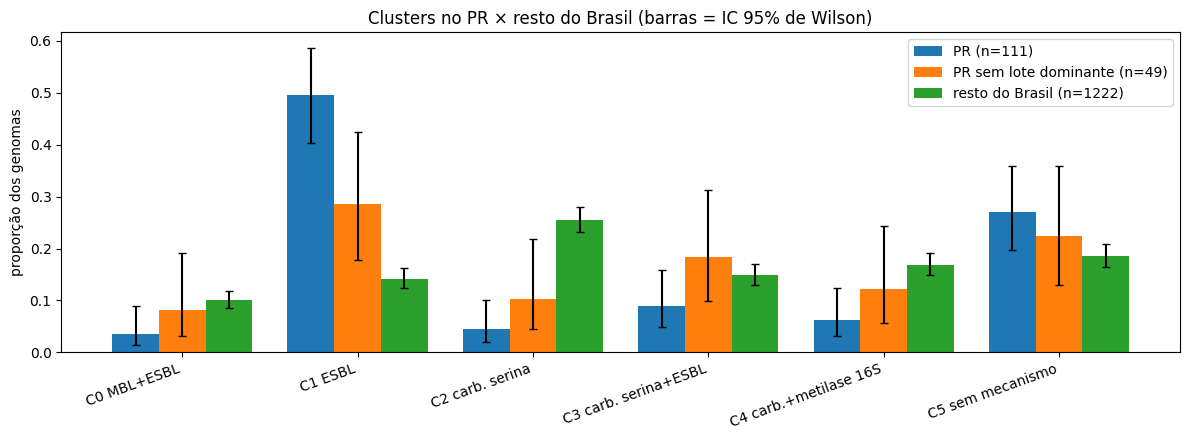

In [7]:
def proporcoes(serie_cl, nome):
    n = len(serie_cl)
    cont = serie_cl.value_counts().reindex(ORDEM, fill_value=0)
    lo, hi = proportion_confint(cont, n, method="wilson")
    return pd.DataFrame({"grupo": nome, "cluster": ORDEM, "n": cont.values, "prop": cont.values / n,
                         "ic_inf": lo.values, "ic_sup": hi.values})


resto = df[df["uf"] == "outras UF"]
comp = pd.concat([
    proporcoes(pr["cl"], f"PR (n={len(pr)})"),
    proporcoes(pr.loc[~pr["lote_dominante"], "cl"], f"PR sem lote dominante (n={(~pr['lote_dominante']).sum()})"),
    proporcoes(resto["cl"], f"resto do Brasil (n={len(resto)})"),
])


def plot_proporcoes(comp, titulo):
    grupos = comp["grupo"].unique()
    x = np.arange(len(ORDEM))
    w = 0.8 / len(grupos)
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for i, g in enumerate(grupos):
        c = comp[comp["grupo"] == g]
        ax.bar(x + i * w, c["prop"], w, label=g,
               yerr=[c["prop"] - c["ic_inf"], c["ic_sup"] - c["prop"]], capsize=3)
    ax.set_xticks(x + w * (len(grupos) - 1) / 2, ORDEM, rotation=20, ha="right")
    ax.set(ylabel="proporção dos genomas", title=titulo)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_proporcoes(comp, "Clusters no PR × resto do Brasil (barras = IC 95% de Wilson)")

Teste de Fisher por cluster (PR × resto do Brasil), com correção de Benjamini-Hochberg para os 6
testes. OR > 1 = cluster mais frequente no PR.

In [8]:
def fisher_por_cluster(a, b, nome_a="PR"):
    linhas = []
    for c in ORDEM:
        tab = [[(a == c).sum(), (a != c).sum()], [(b == c).sum(), (b != c).sum()]]
        odds, p = fisher_exact(tab)
        linhas.append({"cluster": c, f"n_{nome_a}": tab[0][0], f"%_{nome_a}": tab[0][0] / len(a),
                       "%_resto": tab[1][0] / len(b), "odds_ratio": odds, "p": p})
    out = pd.DataFrame(linhas)
    out["p_ajustado_BH"] = multipletests(out["p"], method="fdr_bh")[1]
    return out.round(4)


print("PR completo:")
display(fisher_por_cluster(pr["cl"], resto["cl"]))
print("PR sem o lote dominante:")
display(fisher_por_cluster(pr.loc[~pr["lote_dominante"], "cl"], resto["cl"]))

PR completo:


,cluster,n_PR,%_PR,%_resto,odds_ratio,p,p_ajustado_BH
0,C0 MBL+ESBL,4,0.0360,0.1007,0.3340,0.0266,0.0399
1,C1 ESBL,55,0.4955,0.1416,5.9553,0.0000,0.0000
2,C2 carb. serina,5,0.0450,0.2545,0.1382,0.0000,0.0000
3,C3 carb. serina+ESBL,10,0.0901,0.1489,0.5658,0.1188,0.1188
4,C4 carb.+metilase 16S,7,0.0631,0.1686,0.3320,0.0026,0.0052
5,C5 sem mecanismo,30,0.2703,0.1858,1.6234,0.0434,0.0521


PR sem o lote dominante:


,cluster,n_PR,%_PR,%_resto,odds_ratio,p,p_ajustado_BH
0,C0 MBL+ESBL,4,0.0816,0.1007,0.7942,0.8114,0.8114
1,C1 ESBL,14,0.2857,0.1416,2.4254,0.0115,0.0509
2,C2 carb. serina,5,0.1020,0.2545,0.3329,0.0170,0.0509
3,C3 carb. serina+ESBL,9,0.1837,0.1489,1.2857,0.5390,0.6679
4,C4 carb.+metilase 16S,6,0.1224,0.1686,0.6882,0.5566,0.6679
5,C5 sem mecanismo,11,0.2245,0.1858,1.2688,0.4595,0.6679


**Como ler**: se um cluster só aparece como diferente com o lote dominante incluído, a diferença é
do **estudo**, não necessariamente do estado.

## 4. Espécie, cidade e fonte (PR)

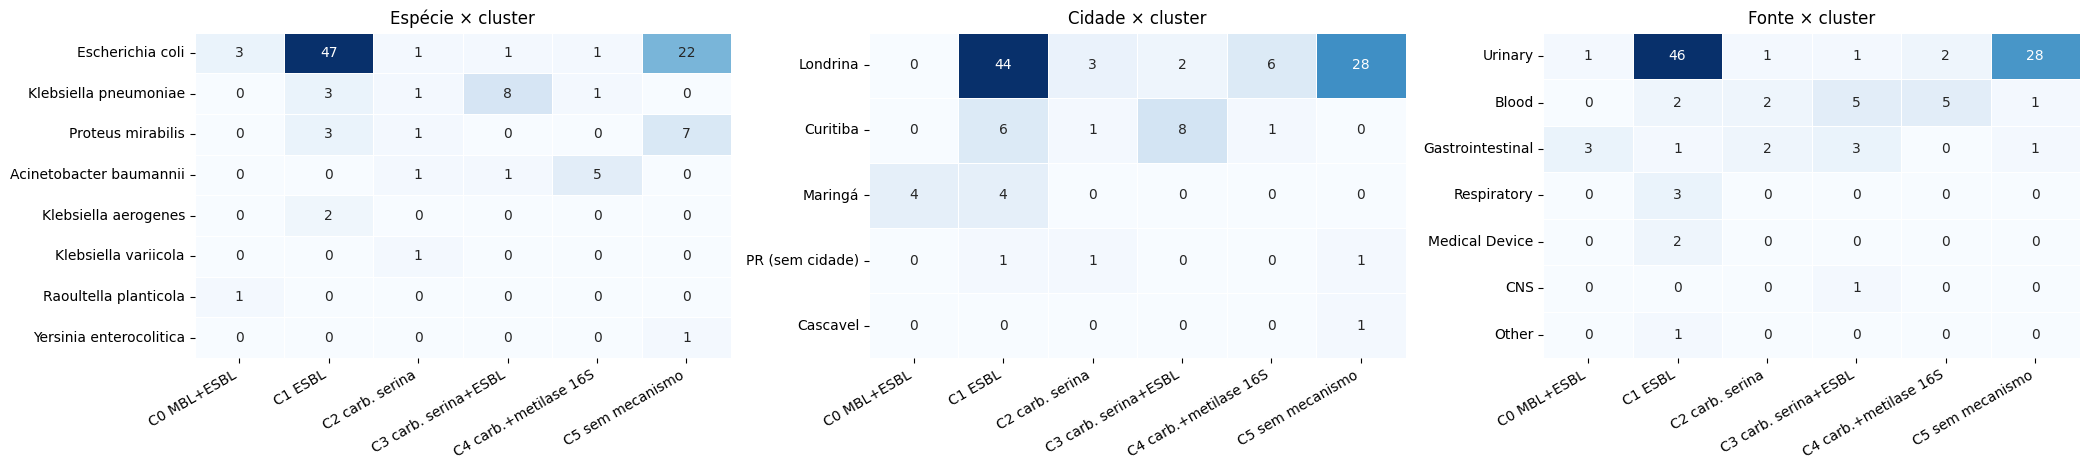

In [9]:
def heatmap_ct(linhas, titulo, ax):
    ct = pd.crosstab(linhas, pr["cl"]).reindex(columns=ORDEM, fill_value=0)
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, linewidths=0.5)
    ax.set(title=titulo, xlabel="", ylabel="")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")


fig, axes = plt.subplots(1, 3, figsize=(21, 4.8))
heatmap_ct(pr["Species"], "Espécie × cluster", axes[0])
heatmap_ct(pr["cidade"], "Cidade × cluster", axes[1])
heatmap_ct(pr["source_type"], "Fonte × cluster", axes[2])
plt.tight_layout()
plt.show()

Mesma visão para cidade × espécie. Isso mostra se "cidade" está só refletindo quem estudou o quê
em cada lugar (Londrina = *E. coli* de urina e *A. baumannii*; Curitiba = *K. pneumoniae*).

In [10]:
pd.crosstab(pr["cidade"], pr["Species"]).loc[lambda d: d.sum(axis=1).sort_values(ascending=False).index]

Species,Acinetobacter baumannii,Escherichia coli,Klebsiella aerogenes,Klebsiella pneumoniae,Klebsiella variicola,Proteus mirabilis,Raoultella planticola,Yersinia enterocolitica
cidade,,,,,,,,
Londrina,7,66,0,0,0,10,0,0
Curitiba,0,1,2,13,0,0,0,0
Maringá,0,7,0,0,0,0,1,0
PR (sem cidade),0,0,0,0,1,1,0,1
Cascavel,0,1,0,0,0,0,0,0


## 5. Linha do tempo

Cada ponto é um genoma, com a cor pelo cluster e o marcador pela espécie. Jitter vertical para
separar os pontos do mesmo ano.

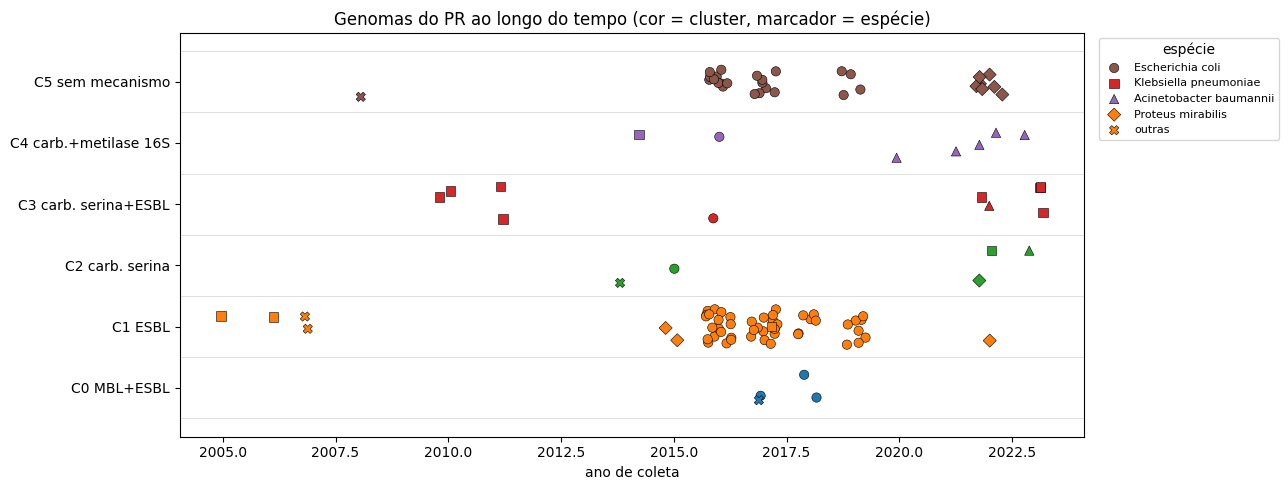

In [11]:
rng = np.random.default_rng(42)
esp4 = pr["Species"].where(pr["Species"].isin(
    ["Escherichia coli", "Klebsiella pneumoniae", "Acinetobacter baumannii", "Proteus mirabilis"]), "outras")
marcadores = {"Escherichia coli": "o", "Klebsiella pneumoniae": "s", "Acinetobacter baumannii": "^",
              "Proteus mirabilis": "D", "outras": "X"}
y = pr["cl"].cat.codes + rng.uniform(-0.3, 0.3, len(pr))
x = pr["Date"] + rng.uniform(-0.3, 0.3, len(pr))

fig, ax = plt.subplots(figsize=(13, 5))
for esp, mk in marcadores.items():
    m = (esp4 == esp).values
    ax.scatter(x[m], y[m], c=[CORES[c] for c in pr.loc[m, "cl"]], marker=mk, s=45,
               edgecolor="k", linewidth=0.4, label=esp)
ax.set_yticks(range(6), ORDEM)
ax.set(xlabel="ano de coleta", title="Genomas do PR ao longo do tempo (cor = cluster, marcador = espécie)")
ax.legend(title="espécie", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
for yy in np.arange(-0.5, 6, 1):
    ax.axhline(yy, c="lightgrey", lw=0.5)
plt.tight_layout()
plt.show()

Carbapenemase (C0, C2, C3, C4) por período, no PR:

In [12]:
pr["tem_carbapenemase"] = pr["cluster"].isin([0, 2, 3, 4])
pr["periodo"] = pd.cut(pr["Date"], [0, 2015, 2019, 3000], labels=["≤2015", "2016–2019", "≥2020"])
tab = pr.groupby("periodo", observed=True).agg(n=("cluster", "size"), n_carbapenemase=("tem_carbapenemase", "sum"))
tab["%"] = (tab["n_carbapenemase"] / tab["n"]).round(2)
tab["especies_com_carbapenemase"] = pr[pr["tem_carbapenemase"]].groupby("periodo", observed=True)["Species"].agg(resumo_top)
tab

,n,n_carbapenemase,%,especies_com_carbapenemase
periodo,,,,
≤2015,14,7,0.50,"Klebsiella pneumoniae (5), Escherichia coli (1)"
2016–2019,76,6,0.08,"Escherichia coli (5), Raoultella planticola (1)"
≥2020,21,13,0.62,"Acinetobacter baumannii (7), Klebsiella pneumoniae (5)"


## 6. *E. coli*: PR × resto do Brasil

Comparar "PR" com "Brasil" mistura efeito de estado com efeito de espécie: o PR tem muito mais *E.
coli* que o resto do país. Restringindo a *E. coli*, a comparação fica justa em espécie. Ainda
assim, no PR ela é quase toda urina de Londrina (lote dominante).

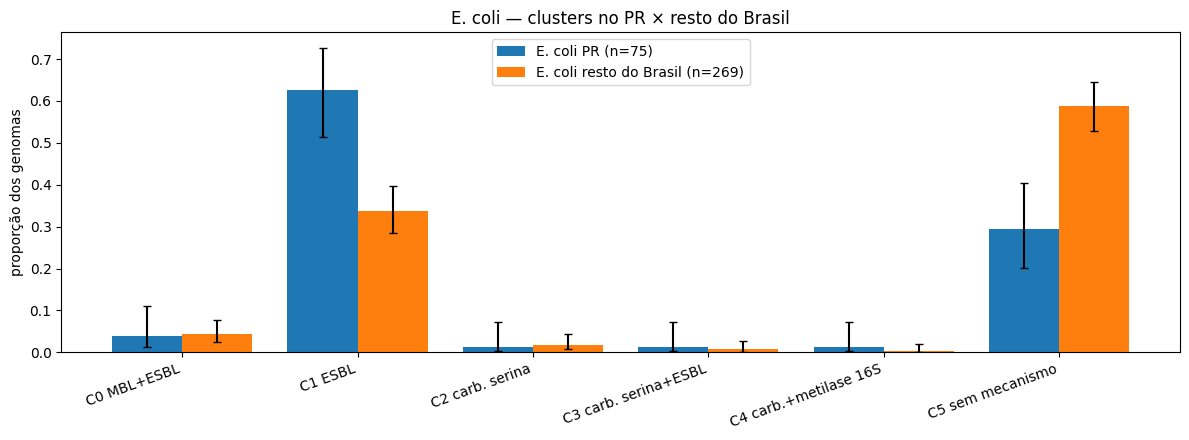

,cluster,n_PR,%_PR,%_resto,odds_ratio,p,p_ajustado_BH
0,C0 MBL+ESBL,3,0.0400,0.0446,0.8924,1.000,1.0000
1,C1 ESBL,47,0.6267,0.3383,3.2834,0.000,0.0000
2,C2 carb. serina,1,0.0133,0.0186,0.7135,1.000,1.0000
3,C3 carb. serina+ESBL,1,0.0133,0.0074,1.8041,0.523,0.7845
4,C4 carb.+metilase 16S,1,0.0133,0.0037,3.6216,0.389,0.7780
5,C5 sem mecanismo,22,0.2933,0.5874,0.2916,0.000,0.0000


In [13]:
ec_pr = pr[pr["Species"] == "Escherichia coli"]
ec_resto = resto[resto["Species"] == "Escherichia coli"]
comp_ec = pd.concat([
    proporcoes(ec_pr["cl"], f"E. coli PR (n={len(ec_pr)})"),
    proporcoes(ec_resto["cl"], f"E. coli resto do Brasil (n={len(ec_resto)})"),
])
plot_proporcoes(comp_ec, "E. coli — clusters no PR × resto do Brasil")
fisher_por_cluster(ec_pr["cl"], ec_resto["cl"], "PR")

Fonte de isolamento das *E. coli*: se o PR é quase só urina e o resto do Brasil é mais fezes/swab
retal (colonização), a diferença de cluster pode ser de **fonte**, não de estado.

In [14]:
pd.concat({"PR": ec_pr["source_type"].value_counts(normalize=True),
           "resto do Brasil": ec_resto["source_type"].value_counts(normalize=True)}, axis=1).fillna(0).round(2)

,PR,resto do Brasil
source_type,,
Urinary,0.92,0.23
Gastrointestinal,0.05,0.64
Blood,0.01,0.08
Medical Device,0.01,0.00
Other,0.00,0.03
Skin & Soft Tissue,0.00,0.01
Unknown,0.00,0.00
Respiratory,0.00,0.00


Controle de fonte: só *E. coli* **urinárias**, PR × resto do Brasil.

In [15]:
ec_pr_u = ec_pr[ec_pr["source_type"] == "Urinary"]
ec_resto_u = ec_resto[ec_resto["source_type"] == "Urinary"]
print(f"E. coli urinária — PR: {len(ec_pr_u)} | resto do Brasil: {len(ec_resto_u)}")
fisher_por_cluster(ec_pr_u["cl"], ec_resto_u["cl"], "PR")

E. coli urinária — PR: 69 | resto do Brasil: 62


,cluster,n_PR,%_PR,%_resto,odds_ratio,p,p_ajustado_BH
0,C0 MBL+ESBL,1,0.0145,0.0323,0.4412,0.6027,1.0
1,C1 ESBL,45,0.6522,0.2097,7.0673,0.0000,0.0
2,C2 carb. serina,0,0.0000,0.0000,NaN,1.0000,1.0
3,C3 carb. serina+ESBL,1,0.0145,0.0000,inf,1.0000,1.0
4,C4 carb.+metilase 16S,1,0.0145,0.0000,inf,1.0000,1.0
5,C5 sem mecanismo,21,0.3043,0.7581,0.1396,0.0000,0.0


## 7. Genes por trás dos clusters no PR

Mesma anotação do notebook 03 (só genes adquiridos, função pelo catálogo NCBI). Aqui: quais ESBLs e
carbapenemases específicas aparecem no PR, e se a variante de ESBL (ex: CTX-M-15 × CTX-M-2/8) difere
do resto do Brasil. A família CTX-M tem forte assinatura geográfica: CTX-M-2 e CTX-M-8 são
historicamente frequentes na América do Sul.

In [16]:
resistome = pd.read_csv(RAIZ / "data/raw/resistome_recorte.csv",
                        usecols=["sample_id", "gene_clean", "amr_gene_family", "model_type", "contig_type"])
resistome = resistome[resistome["sample_id"].isin(df.index)]
anotado = anotar_resistoma_risco(resistome, df["Species"], CatalogoBetaLactamase(RAIZ / "data/raw/refgenes.tsv"))
adq = anotado[anotado["categoria"].notna()].copy()
adq["regiao"] = adq["sample_id"].map(df["uf"])
adq["cl"] = adq["sample_id"].map(df["cl"])

### 7.1 Carbapenemases e ESBLs no PR, por cluster

In [17]:
adq_pr = adq[adq["regiao"] == "PR"]
for cat, titulo in [("bl_carbapenemase", "Carbapenemases"), ("bl_esbl", "ESBLs")]:
    sub = adq_pr[adq_pr["categoria"] == cat]
    ct = pd.crosstab(sub["gene_clean"], sub["cl"]).reindex(columns=ORDEM, fill_value=0)
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    print(f"\n{titulo} no PR (nº de genomas):")
    display(ct)


Carbapenemases no PR (nº de genomas):


cl,C0 MBL+ESBL,C1 ESBL,C2 carb. serina,C3 carb. serina+ESBL,C4 carb.+metilase 16S,C5 sem mecanismo
gene_clean,,,,,,
KPC-2,1,0,3,8,1,0
OXA-23-like,0,0,1,1,5,0
NDM-1,4,0,0,0,3,0
GES-5,0,0,1,0,0,0
KPC-3,0,0,0,1,0,0



ESBLs no PR (nº de genomas):


cl,C0 MBL+ESBL,C1 ESBL,C2 carb. serina,C3 carb. serina+ESBL,C4 carb.+metilase 16S,C5 sem mecanismo
gene_clean,,,,,,
CTX-M-15,1,17,0,9,0,0
CTX-M-8,0,11,0,0,0,0
CTX-M-14,0,7,0,1,2,0
CTX-M-2,0,9,0,0,0,0
CTX-M-55,0,7,0,0,0,0
CTX-M-27,0,3,0,0,0,0
CTX-M-24,0,2,0,1,0,0
CTX-M-157,0,2,0,0,0,0
CTX-M-3,0,1,0,0,0,0


### 7.1b Todos os genomas do PR com carbapenemase

Com n pequeno, a lista individual diz mais que as proporções. Atenção a **coprodução** (duas
carbapenemases no mesmo genoma, ex: NDM-1 + OXA-23 em *A. baumannii*): o KMeans coloca esses
genomas no C4 (metilase 16S) e não no C0 (MBL), porque a metilase pesa mais na distância. O rótulo
do cluster resume o perfil, não substitui olhar o gene.

In [18]:
carb_pr = (adq_pr[adq_pr["categoria"] == "bl_carbapenemase"]
           .groupby("sample_id").agg(carbapenemases=("gene_clean", lambda s: " + ".join(sorted(set(s)))),
                                     em_plasmideo=("plasmidial", "any")))
lista = pr[["Species", "cidade", "Date", "source_type", "cl"]].join(carb_pr, how="inner")
lista["Date"] = lista["Date"].astype("Int64")
lista.sort_values(["carbapenemases", "Date"])

,Species,cidade,Date,source_type,cl,carbapenemases,em_plasmideo
GCA_016598855.1,Klebsiella variicola,PR (sem cidade),2014,Gastrointestinal,C2 carb. serina,GES-5,True
GCA_013180525.1,Klebsiella pneumoniae,Curitiba,2010,CNS,C3 carb. serina+ESBL,KPC-2,True
GCA_013180515.1,Klebsiella pneumoniae,Curitiba,2010,Gastrointestinal,C3 carb. serina+ESBL,KPC-2,True
GCA_013180445.1,Klebsiella pneumoniae,Curitiba,2011,Gastrointestinal,C3 carb. serina+ESBL,KPC-2,True
GCA_013180465.1,Klebsiella pneumoniae,Curitiba,2011,Blood,C3 carb. serina+ESBL,KPC-2,True
GCA_035615435.1,Klebsiella pneumoniae,Curitiba,2014,Blood,C4 carb.+metilase 16S,KPC-2,True
GCA_019249965.1,Escherichia coli,Londrina,2015,Blood,C2 carb. serina,KPC-2,True
GCA_016991735.1,Escherichia coli,Londrina,2016,Urinary,C3 carb. serina+ESBL,KPC-2,True
GCA_042875785.1,Proteus mirabilis,Londrina,2022,Urinary,C2 carb. serina,KPC-2,True
GCA_049381405.1,Klebsiella pneumoniae,Curitiba,2022,Gastrointestinal,C2 carb. serina,KPC-2,True


In [19]:
lista.groupby(["carbapenemases", "Species"]).size().rename("n").to_frame()

n
carbapenemases      Species                   
GES-5               Klebsiella variicola     1
KPC-2               Escherichia coli         2
                    Klebsiella pneumoniae    9
                    Proteus mirabilis        1
KPC-2 + NDM-1       Raoultella planticola    1
KPC-3               Klebsiella pneumoniae    1
NDM-1               Escherichia coli         3
NDM-1 + OXA-23-like Acinetobacter baumannii  3
OXA-23-like         Acinetobacter baumannii  4

### 7.2 Variante de ESBL: PR × resto do Brasil

Fração dos genomas **com ESBL** que carrega cada variante (um genoma pode ter mais de uma).

genomas com ESBL: {'PR': 68, 'outras UF': 533}


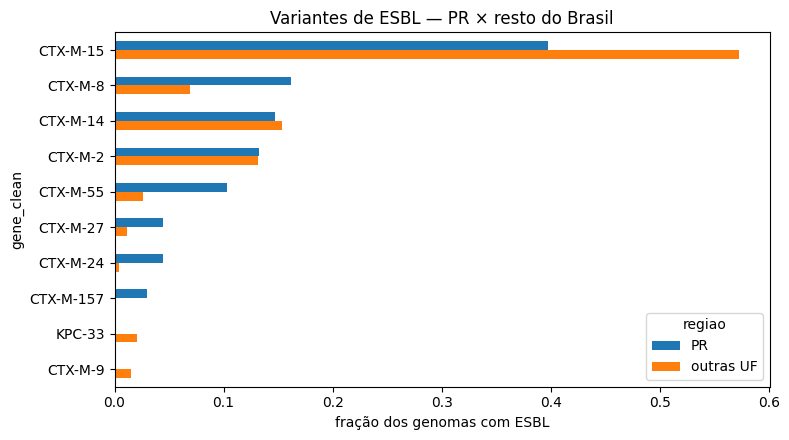

regiao,PR,outras UF
gene_clean,,
CTX-M-15,0.40,0.57
CTX-M-8,0.16,0.07
CTX-M-14,0.15,0.15
CTX-M-2,0.13,0.13
CTX-M-55,0.10,0.03
CTX-M-27,0.04,0.01
CTX-M-24,0.04,0.00
CTX-M-157,0.03,0.00
KPC-33,0.00,0.02


In [20]:
esbl = adq[(adq["categoria"] == "bl_esbl") & adq["regiao"].isin(["PR", "outras UF"])]
n_com_esbl = esbl.groupby("regiao")["sample_id"].nunique()
frac = (esbl.groupby(["gene_clean", "regiao"])["sample_id"].nunique().unstack(fill_value=0) / n_com_esbl)
frac = frac.loc[frac.max(axis=1).sort_values(ascending=False).index].head(10)
print("genomas com ESBL:", n_com_esbl.to_dict())

frac.plot(kind="barh", figsize=(8, 4.5))
plt.gca().invert_yaxis()
plt.xlabel("fração dos genomas com ESBL")
plt.title("Variantes de ESBL — PR × resto do Brasil")
plt.tight_layout()
plt.show()
frac.round(2)

### 7.3 Carga de resistência adquirida por cluster (PR × resto)

Nº de classes de droga com resistência adquirida, uma medida de multirresistência que não entrou
no clustering. Se o mesmo cluster tem carga parecida no PR e no resto do Brasil, o cluster
significa a mesma coisa nos dois lugares.

In [21]:
from notebooks.src.features_risco import build_features_risco

feats = build_features_risco(anotado, df.index)
tmp = df[["cl", "uf"]].join(feats[["n_classes_adquiridas", "n_genes_adquiridos"]])
tmp = tmp[tmp["uf"].isin(["PR", "outras UF"])]
(tmp.groupby(["cl", "uf"], observed=True)["n_classes_adquiridas"]
 .agg(["count", "median", "mean"]).round(2).unstack("uf"))

count           median            mean          
uf                       PR outras UF     PR outras UF    PR outras UF
cl                                                                    
C0 MBL+ESBL               4       123    7.5       5.0  6.75      5.23
C1 ESBL                  55       173    6.0       5.0  5.35      5.08
C2 carb. serina           5       311    4.0       4.0  4.20      4.27
C3 carb. serina+ESBL     10       182    6.0       6.0  5.40      5.50
C4 carb.+metilase 16S     7       206    6.0       6.0  6.43      5.90
C5 sem mecanismo         30       227    3.0       2.0  3.13      2.44

## 8. Resumo

Tabela-síntese gerada a partir dos resultados acima (as conclusões em texto estão no report).

In [22]:
sintese = pd.DataFrame({
    "PR (n)": pr["cl"].value_counts().reindex(ORDEM),
    "PR %": pr["cl"].value_counts(normalize=True).reindex(ORDEM).round(3),
    "PR sem lote dominante %": pr.loc[~pr["lote_dominante"], "cl"].value_counts(normalize=True).reindex(ORDEM).round(3),
    "resto do Brasil %": resto["cl"].value_counts(normalize=True).reindex(ORDEM).round(3),
    "espécies no PR": pr.groupby("cl", observed=True)["Species"].agg(lambda s: resumo_top(s, 3)),
    "cidades no PR": pr.groupby("cl", observed=True)["cidade"].agg(lambda s: resumo_top(s, 3)),
})
sintese

,PR (n),PR %,PR sem lote dominante %,resto do Brasil %,espécies no PR,cidades no PR
cl,,,,,,
C0 MBL+ESBL,4,0.036,0.082,0.101,"Escherichia coli (3), Raoultella planticola (1)",Maringá (4)
C1 ESBL,55,0.495,0.286,0.142,"Escherichia coli (47), Klebsiella pneumoniae (3), Proteus mirabilis (3)","Londrina (44), Curitiba (6), Maringá (4)"
C2 carb. serina,5,0.045,0.102,0.255,"Escherichia coli (1), Klebsiella variicola (1), Proteus mirabilis (1)","Londrina (3), PR (sem cidade) (1), Curitiba (1)"
C3 carb. serina+ESBL,10,0.090,0.184,0.149,"Klebsiella pneumoniae (8), Escherichia coli (1), Acinetobacter baumannii (1)","Curitiba (8), Londrina (2)"
C4 carb.+metilase 16S,7,0.063,0.122,0.169,"Acinetobacter baumannii (5), Escherichia coli (1), Klebsiella pneumoniae (1)","Londrina (6), Curitiba (1)"
C5 sem mecanismo,30,0.270,0.224,0.186,"Escherichia coli (22), Proteus mirabilis (7), Yersinia enterocolitica (1)","Londrina (28), Cascavel (1), PR (sem cidade) (1)"


### Conclusões (conferidas com os resultados acima)

1. **O PR é dominado por um estudo**: 62 dos 111 genomas (56%) são *E. coli* de urina de Londrina
   (2016–2019), de um único lote de BioSamples. Qualquer "perfil do PR" é, em boa parte, o perfil
   desse estudo.
2. **Excesso de C1 (ESBL sem carbapenemase)**: 50% no PR × 14% no resto do Brasil. Ele persiste sem
   o lote dominante (29%, p ajustado ≈ 0,05) e dentro de *E. coli* urinária (65% × 21%). Não dá para
   separar efeito regional de critério de seleção do estudo: se o estudo selecionou isolados
   resistentes, o excesso é de desenho amostral.
3. **Falta de C2 (carbapenemase de serina sozinha)**: 5% × 25%. É efeito de espécie: o C2 nacional é
   puxado por *A. baumannii* e *K. pneumoniae*, que são poucos no PR.
4. **Variantes de ESBL**: o PR tem mais CTX-M-8 (16% × 7%) e CTX-M-55 (10% × 3%), e menos CTX-M-15
   (40% × 57%). Vale reportar como hipótese: as CTX-M têm assinatura geográfica e de plasmídeo.
5. **Carbapenemases no PR** (25 genomas): KPC-2 em *K. pneumoniae* de Curitiba desde 2010; NDM-1 em
   *E. coli* e *Raoultella* de Maringá (2017–2018, esta com KPC-2 + NDM-1); e **NDM-1 + OXA-23 em
   *A. baumannii* de Londrina (2022–2023)**, dois de sangue. Coprodução MBL + OXA em *A. baumannii* é
   o perfil com menos opção terapêutica do recorte.
6. **Tendência temporal** (% com carbapenemase: 50% até 2015, 8% em 2016–19, 62% a partir de 2020):
   **não interpretar como tendência**. Cada período é um lote/estudo diferente (KPC em Curitiba → *E.
   coli* urinária em Londrina → *A. baumannii* em Londrina).
7. O **mesmo cluster significa a mesma coisa** no PR e no resto do país: a carga de classes adquiridas
   por cluster é praticamente igual (seção 7.3). Isso reforça que os clusters generalizam entre
   regiões.